In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Book_Review_Dataset.zip to Book_Review_Dataset.zip


In [5]:
import zipfile
import os

# Get uploaded ZIP filename
zip_file = list(uploaded.keys())[0]

# Extract ZIP
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("ZIP Extracted Successfully")

ZIP Extracted Successfully


In [6]:
os.listdir("dataset")

['1. Book Review Dataset']

In [7]:
os.listdir("dataset/1. Book Review Dataset")

['Book_review.csv', '1. Description - Book Review Dataset.txt']

In [8]:
df = pd.read_csv("dataset/1. Book Review Dataset/Book_review.csv")

df.head()

,Unnamed: 0,rating,reviewText,summary
0,0,5,This book was the very first bookmobile book I...,50 + years ago...
1,1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!
2,2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!
3,3,5,I don't normally buy 'mystery' novels because ...,Very good read.
4,4,5,"This isn't the kind of book I normally read, a...",Great Story!


In [9]:
df.columns

Index(['Unnamed: 0', 'rating', 'reviewText', 'summary'], dtype='object')

In [10]:
df = df[['rating', 'reviewText']]

df.dropna(inplace=True)

df.head()

,rating,reviewText
0,5,This book was the very first bookmobile book I...
1,1,"When I read the description for this book, I c..."
2,5,I just had to edit this review. This book is a...
3,5,I don't normally buy 'mystery' novels because ...
4,5,"This isn't the kind of book I normally read, a..."


In [11]:
def label_sentiment(rating):

    if rating <= 2:
        return 0

    elif rating == 3:
        return 1

    else:
        return 2

df['sentiment'] = df['rating'].apply(label_sentiment)

df.head()

,rating,reviewText,sentiment
0,5,This book was the very first bookmobile book I...,2
1,1,"When I read the description for this book, I c...",0
2,5,I just had to edit this review. This book is a...,2
3,5,I don't normally buy 'mystery' novels because ...,2
4,5,"This isn't the kind of book I normally read, a...",2


In [12]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'http\S+|www\S+', '', text)

    text = re.sub(r'@\w+', '', text)

    text = re.sub(r'#', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['cleaned_review'] = df['reviewText'].apply(clean_text)

df.head()

,rating,reviewText,sentiment,cleaned_review
0,5,This book was the very first bookmobile book I...,2,this book was the very first bookmobile book i...
1,1,"When I read the description for this book, I c...",0,when i read the description for this book i co...
2,5,I just had to edit this review. This book is a...,2,i just had to edit this review this book is an...
3,5,I don't normally buy 'mystery' novels because ...,2,i dont normally buy mystery novels because i j...
4,5,"This isn't the kind of book I normally read, a...",2,this isnt the kind of book i normally read alt...


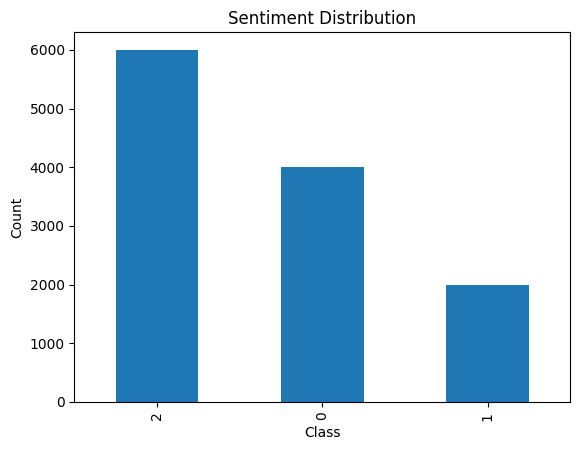

In [13]:
df['sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

In [14]:
X = df['cleaned_review']

y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train Size:", len(X_train))
print("Test Size:", len(X_test))

Train Size: 9600
Test Size: 2400


In [15]:
vocab_size = 10000

max_len = 100

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

In [16]:
tokenizer.fit_on_texts(X_train)

word_index = tokenizer.word_index

print("Vocabulary Size:", len(word_index))

Vocabulary Size: 39402


In [17]:
X_train_seq = tokenizer.texts_to_sequences(X_train)

X_test_seq = tokenizer.texts_to_sequences(X_test)

In [18]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

print(X_train_pad.shape)
print(X_test_pad.shape)

(9600, 100)
(2400, 100)


In [19]:
y_train = np.array(y_train)

y_test = np.array(y_test)

In [20]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [21]:
model_rnn = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=100,
        input_length=max_len
    ),

    SimpleRNN(64),

    Dropout(0.5),

    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [22]:
model_rnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.4783 - loss: 1.0306 - val_accuracy: 0.4979 - val_loss: 1.0161
Epoch 2/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.5445 - loss: 0.9573 - val_accuracy: 0.4896 - val_loss: 1.0322
Epoch 3/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.6254 - loss: 0.8370 - val_accuracy: 0.4443 - val_loss: 1.0810
Epoch 4/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.6779 - loss: 0.7093 - val_accuracy: 0.4714 - val_loss: 1.1282


In [24]:
rnn_pred = np.argmax(
    model_rnn.predict(X_test_pad),
    axis=1
)

print("RNN Accuracy:", accuracy_score(y_test, rnn_pred))

print(classification_report(y_test, rnn_pred))

print(confusion_matrix(y_test, rnn_pred))

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
RNN Accuracy: 0.4925
              precision    recall  f1-score   support

           0       0.25      0.01      0.01       799
           1       0.00      0.00      0.00       412
           2       0.50      0.99      0.66      1189

    accuracy                           0.49      2400
   macro avg       0.25      0.33      0.22      2400
weighted avg       0.33      0.49      0.33      2400

[[   6    1  792]
 [   5    0  407]
 [  13    0 1176]]


In [25]:
model_lstm = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=100,
        input_length=max_len
    ),

    LSTM(64),

    Dropout(0.5),

    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [26]:
model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.4945 - loss: 1.0190 - val_accuracy: 0.4969 - val_loss: 1.0095
Epoch 2/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - accuracy: 0.5169 - loss: 0.9930 - val_accuracy: 0.5063 - val_loss: 1.0062
Epoch 3/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - accuracy: 0.5630 - loss: 0.9368 - val_accuracy: 0.5036 - val_loss: 1.3919
Epoch 4/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - accuracy: 0.5540 - loss: 0.9506 - val_accuracy: 0.5214 - val_loss: 1.0331
Epoch 5/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 20s 67ms/step - accuracy: 0.6639 - loss: 0.7682 - val_accuracy: 0.6698 - val_loss: 0.8962
Epoch 6/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.7850 - loss: 0.5897 - val_accuracy: 0.6740 - val_loss: 0.8579
Epoch 7/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 22s 72ms/step - accuracy: 0.8288 - loss: 0.4762 - val_accuracy: 0.6964 - val_loss: 0.9115
Epoch 8/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.8600 - loss: 0.3926 - 

In [28]:
lstm_pred = np.argmax(
    model_lstm.predict(X_test_pad),
    axis=1
)

print("LSTM Accuracy:", accuracy_score(y_test, lstm_pred))

print(classification_report(y_test, lstm_pred))

print(confusion_matrix(y_test, lstm_pred))

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
LSTM Accuracy: 0.6804166666666667
              precision    recall  f1-score   support

           0       0.68      0.73      0.70       799
           1       0.24      0.07      0.11       412
           2       0.72      0.86      0.78      1189

    accuracy                           0.68      2400
   macro avg       0.55      0.55      0.53      2400
weighted avg       0.62      0.68      0.64      2400

[[ 580   55  164]
 [ 150   30  232]
 [ 125   41 1023]]


In [29]:
!pip install gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.2 MB/s eta 0:00:00


In [30]:
import gensim.downloader as api

glove_model = api.load("glove-wiki-gigaword-50")

[==================================================] 100.0% 66.0/66.0MB downloaded


In [31]:
embedding_dim = 50

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():

    if i < vocab_size:

        try:
            embedding_matrix[i] = glove_model[word]

        except KeyError:
            pass

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (10000, 50)


In [32]:
model_glove_lstm = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False
    ),

    LSTM(64),

    Dropout(0.5),

    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [33]:
model_glove_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_glove_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

In [34]:
history_glove_lstm = model_glove_lstm.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 29s 107ms/step - accuracy: 0.4962 - loss: 1.0269 - val_accuracy: 0.5094 - val_loss: 1.0015
Epoch 2/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.5064 - loss: 1.0029 - val_accuracy: 0.5349 - val_loss: 0.9953
Epoch 3/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.5195 - loss: 0.9962 - val_accuracy: 0.5010 - val_loss: 0.9605


In [35]:
glove_pred = np.argmax(
    model_glove_lstm.predict(X_test_pad),
    axis=1
)

print("GloVe LSTM Accuracy:", accuracy_score(y_test, glove_pred))

print(classification_report(y_test, glove_pred))

print(confusion_matrix(y_test, glove_pred))

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
GloVe LSTM Accuracy: 0.505
              precision    recall  f1-score   support

           0       0.47      0.12      0.19       799
           1       0.00      0.00      0.00       412
           2       0.51      0.94      0.66      1189

    accuracy                           0.51      2400
   macro avg       0.33      0.35      0.28      2400
weighted avg       0.41      0.51      0.39      2400

[[  96    0  703]
 [  35    0  377]
 [  73    0 1116]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [36]:
def plot_history(history, model_name):

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(model_name + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(model_name + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

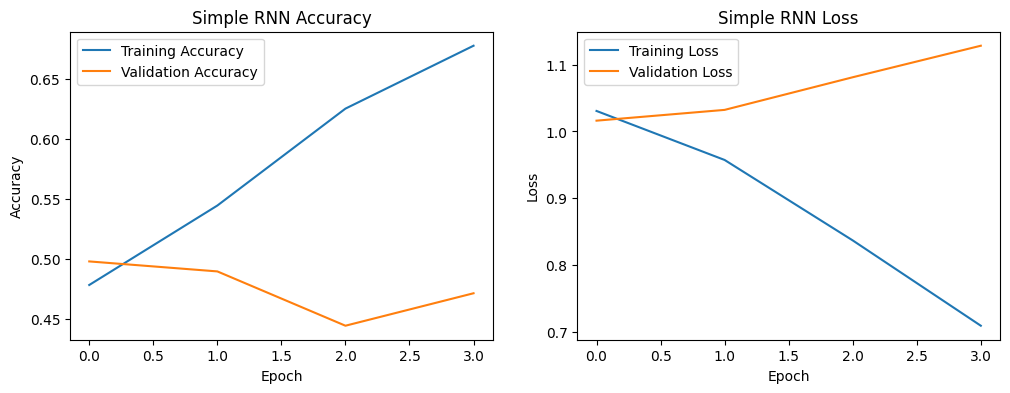

In [37]:
plot_history(history_rnn, "Simple RNN")

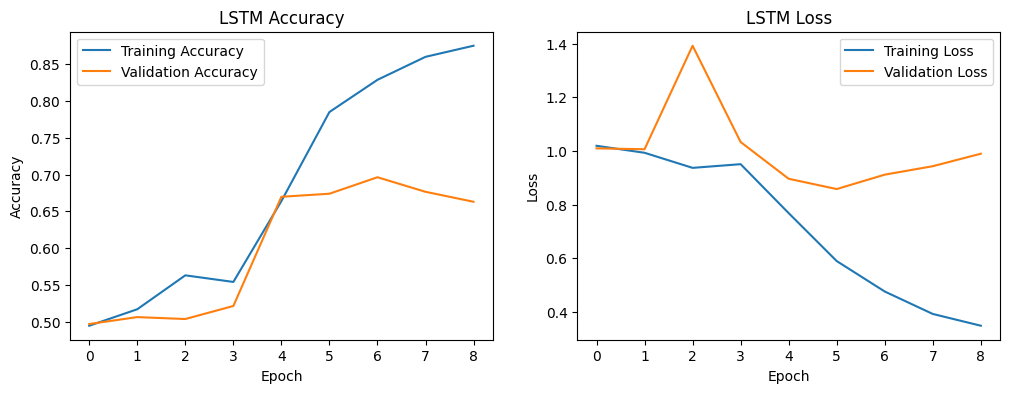

In [38]:
plot_history(history_lstm, "LSTM")

In [39]:
rnn_acc = accuracy_score(y_test, rnn_pred)

lstm_acc = accuracy_score(y_test, lstm_pred)

glove_acc = accuracy_score(y_test, glove_pred)

print("RNN Accuracy:", rnn_acc)
print("LSTM Accuracy:", lstm_acc)
print("GloVe LSTM Accuracy:", glove_acc)

RNN Accuracy: 0.4925
LSTM Accuracy: 0.6804166666666667
GloVe LSTM Accuracy: 0.505


In [40]:
comparison_df = pd.DataFrame({
    "Model": [
        "Simple RNN",
        "LSTM",
        "LSTM with GloVe"
    ],
    "Accuracy": [
        rnn_acc,
        lstm_acc,
        glove_acc
    ]
})

comparison_df

,Model,Accuracy
0,Simple RNN,0.492500
1,LSTM,0.680417
2,LSTM with GloVe,0.505000


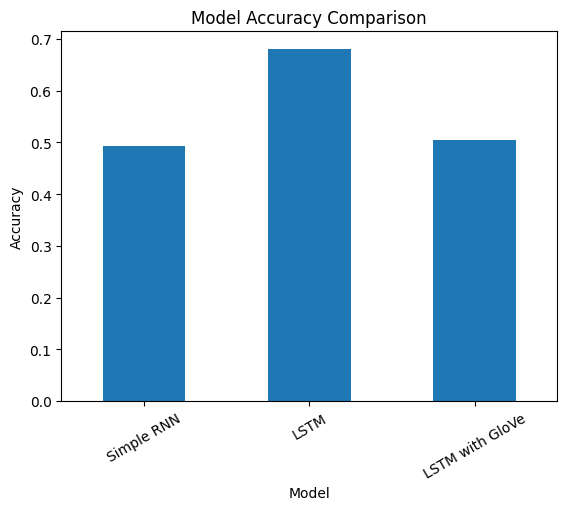

In [41]:
comparison_df.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

In [42]:
def show_confusion_matrix(y_true, y_pred, title):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.colorbar()

    labels = ["Negative", "Neutral", "Positive"]
    plt.xticks([0, 1, 2], labels)
    plt.yticks([0, 1, 2], labels)

    for i in range(len(cm)):
        for j in range(len(cm[i])):
            plt.text(j, i, cm[i][j], ha="center", va="center")

    plt.show()

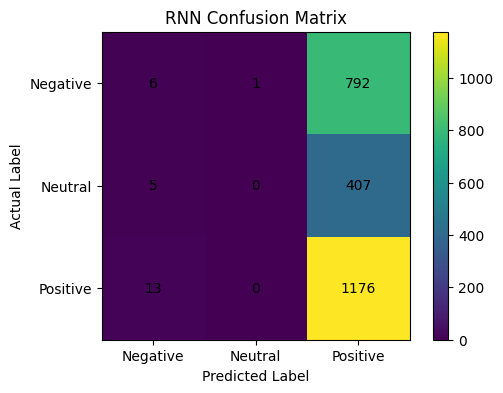

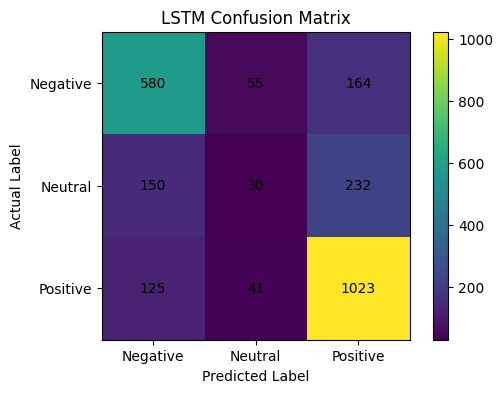

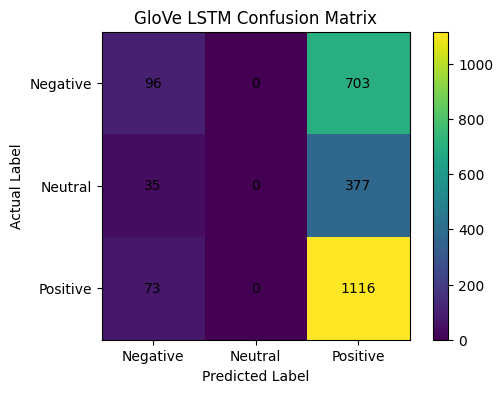

In [43]:
show_confusion_matrix(y_test, rnn_pred, "RNN Confusion Matrix")

show_confusion_matrix(y_test, lstm_pred, "LSTM Confusion Matrix")

show_confusion_matrix(y_test, glove_pred, "GloVe LSTM Confusion Matrix")

In [44]:
label_names = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

print(label_names)

{0: 'Negative', 1: 'Neutral', 2: 'Positive'}


In [45]:
error_df = pd.DataFrame({
    "Review": X_test.values,
    "Actual": y_test,
    "Predicted": glove_pred
})

wrong_predictions = error_df[error_df["Actual"] != error_df["Predicted"]]

wrong_predictions.head()

,Review,Actual,Predicted
1,when i was a child my parents loved these stor...,1,2
4,while the plot had promise the story just didn...,0,2
6,possibly the worst romance ive read i kept rea...,0,2
7,the title drew me in something scarry lives un...,0,2
8,i think her main goal is to sell you her books...,0,2


In [46]:
wrong_predictions["Actual_Label"] = wrong_predictions["Actual"].map(label_names)

wrong_predictions["Predicted_Label"] = wrong_predictions["Predicted"].map(label_names)

wrong_predictions.head()

/tmp/ipykernel_4494/2602499016.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wrong_predictions["Actual_Label"] = wrong_predictions["Actual"].map(label_names)
/tmp/ipykernel_4494/2602499016.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wrong_predictions["Predicted_Label"] = wrong_predictions["Predicted"].map(label_names)


,Review,Actual,Predicted,Actual_Label,Predicted_Label
1,when i was a child my parents loved these stor...,1,2,Neutral,Positive
4,while the plot had promise the story just didn...,0,2,Negative,Positive
6,possibly the worst romance ive read i kept rea...,0,2,Negative,Positive
7,the title drew me in something scarry lives un...,0,2,Negative,Positive
8,i think her main goal is to sell you her books...,0,2,Negative,Positive


In [47]:
for i, row in wrong_predictions.head(3).iterrows():

    print("Review:", row["Review"])

    print("Actual Sentiment:", row["Actual_Label"])

    print("Predicted Sentiment:", row["Predicted_Label"])

    print("-" * 80)

Review: when i was a child my parents loved these stories made into several movies and of course i thought they were boring and old fashionedwell theyre still old fashioned but in a comforting old world way the stories are set in the british isles for the most part between wwi and wwii bulldog drummond makes a habit of saving damsels in distress with flair and dash theres no bad language course innuendo or explicit sex or violence just interesting narrative and story lines great for a quiet rainy sunday
Actual Sentiment: Neutral
Predicted Sentiment: Positive
--------------------------------------------------------------------------------
Review: while the plot had promise the story just didnt deliver the characters were more caricature than realistic the story appeared to be a more of cross between pretty woman and a fairy tale than a contemporary romance
Actual Sentiment: Negative
Predicted Sentiment: Positive
---------------------------------------------------------------------------

In [48]:
def predict_sentiment(text):

    cleaned = clean_text(text)

    sequence = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        sequence,
        maxlen=max_len,
        padding='post',
        truncating='post'
    )

    prediction = model_glove_lstm.predict(padded)

    predicted_class = np.argmax(prediction, axis=1)[0]

    return label_names[predicted_class]

In [49]:
predict_sentiment("This book is very interesting and useful")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


'Positive'

In [50]:
predict_sentiment("This book is boring and not good")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


'Positive'

In [51]:
!pip install gradio -q

In [52]:
import gradio as gr

In [53]:
def gradio_predict(review):

    result = predict_sentiment(review)

    return result


interface = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(
        lines=5,
        placeholder="Enter a book review here..."
    ),
    outputs="text",
    title="Book Review Sentiment Analysis",
    description="This app predicts whether a book review is Negative, Neutral, or Positive."
)

In [54]:
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9e4dd27c977e8fed10.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
